# Question A4

In this section, we will understand the utility of such a neural network in real world scenarios.

#### Please use the real record data named ‘record.wav’  as a test sample. Preprocess the data using the provided preprocessing script (data_preprocess.ipynb) and prepare the dataset.
Do a model prediction on the sample test dataset and obtain the predicted label using a threshold of 0.5. The model used is the optimized pretrained model using the selected optimal batch size and optimal number of neurons.
Find the top 3 most important features on the model prediction for the test sample using SHAP. Plot the local feature importance with a force plot and explain your observations. (Refer to the documentation and these three useful references:
https://christophm.github.io/interpretable-ml-book/shap.html#examples-5,
https://towardsdatascience.com/deep-learning-model-interpretation-using-shap-a21786e91d16,  
https://medium.com/mlearning-ai/shap-force-plots-for-classification-d30be430e195)



1. Firstly, we import relevant libraries.

In [1]:
import tqdm
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from scipy.io import wavfile as wav

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from common_utils import set_seed

# setting seed
set_seed()

C:\Users\chooz\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\chooz\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


To reduce repeated code, place your
network (MLP defined in QA1)
torch datasets (CustomDataset defined in QA1)
loss function (loss_fn defined in QA1)
in a separate file called common_utils.py

Import them into this file. You will not be repenalised for any error in QA1 here as the code in QA1 will not be remarked.

The following code cell will not be marked.


In [4]:
# YOUR CODE HERE
from common_utils import EarlyStopper, loss_fn, MLP, CustomDataset, split_dataset, preprocess_dataset, train_loop, test_loop

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

no_features = 77
no_labels = 1
optimal_no_hidden = [256, 128]
dropout_rate = 0.3

batch_size = 64
weight_decay = 0.0005
max_epochs = 200
patience = 5

no_folds = 5

seed = 42

# setting seed
set_seed(seed)

# Model Trained from Part A3
model = MLP(no_features, optimal_no_hidden, no_labels, dropout_rate).to(device)
model.load_state_dict(torch.load('a3model.pth', weights_only = True))
model.eval()

MLP(
  (mlp_stack): Sequential(
    (0): Linear(in_features=77, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

2. Install and import shap

In [223]:
# YOUR CODE HERE
!pip install shap

In [6]:
import shap

3. Read the csv data preprocessed from 'record.wav', using variable name 'df', and fill the size of 'df' in 'size_row' and 'size_column'.

In [10]:
# YOUR CODE HERE
df = pd.read_csv('new_record.csv')
size_row, size_column = df.shape

print(f"Rows: {size_row}, Columns: {size_column}")

Rows: 1, Columns: 78


In [12]:
display(df)

,filename,tempo,total_beats,average_beats,chroma_stft_mean,chroma_stft_var,chroma_cq_mean,chroma_cq_var,chroma_cens_mean,chroma_cens_var,...,mfcc15_mean,mfcc15_var,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var
0,record.wav,[112.34714674],280,70.0,0.478361,0.111058,0.579547,0.091646,0.268037,0.01149,...,-4.068467,46.232433,-4.134901,53.040028,-0.942353,35.105545,-3.529712,54.78144,-3.722852,53.242016


 4.  Preprocess to obtain the test data, save the test data as numpy array.

In [16]:
def preprocess(X_train, df):
    """preprocess your dataset to obtain your test dataset, remember to remove the 'filename' as Q1
    """
    # YOUR CODE HERE
    df['tempo'] = df['tempo'].astype(str).str.strip('[]').astype(float)
    X_test = df.drop(columns=['filename']).to_numpy()
    X_train_scaled_eg, X_test_scaled_eg = preprocess_dataset(X_train, X_test)

    return X_test_scaled_eg

df_train = pd.read_csv('simplified.csv')
df_train['label'] = df_train['filename'].str.split('').str[-2]
X_train, y_train, X_test, y_test = split_dataset(df_train, columns_to_drop = ['filename', 'label'], test_size = 0.25, random_state = seed)
X_train_scaled, X_test_scaled = preprocess_dataset(X_train, X_test)

X_test_scaled_eg = preprocess(X_train, df)
print(X_test_scaled_eg.shape)
print(X_test_scaled_eg.ndim)

(1, 77)
2


C:\Users\chooz\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


5. Do a model prediction on the sample test dataset and obtain the predicted label using a threshold of 0.5. The model used is the optimized pretrained model using the selected optimal learning rate and optimal architecture. Note: Please define the variable of your final predicted label as 'pred_label'.

In [22]:
# YOUR CODE HERE

# Sanity Check for Model
"""
Sanity Check is a quick test to verify if a model is working correctly before using it on real data. It catches issues like the model not being loaded 
properly, being in training mode instead of eval mode, or outputting garbage values.

Sanity check runs one training sample through the model and outputs a probability between 0 and 1 (from the sigmoid layer). For example 0.0882 means the 
model is 8.82% confident that sample belongs to class 1, so it would be classified as class 0.
"""
X_sanity = torch.tensor(X_train_scaled[:1], dtype=torch.float32).to(device)
with torch.no_grad():
    out = model(X_sanity).squeeze(1)
    print(f"Sanity check probability: {out.item():.10f}")
    
with torch.no_grad():
    X_tensor = torch.tensor(X_test_scaled_eg, dtype=torch.float32).to(device)
    output = model(X_tensor)
    pred_label = (output >= 0.5).float().cpu().numpy()

print(f"Raw model output (probability): {output.cpu().numpy()[0][0]:.10f}")
print(f"Predicted label (0 or 1): {pred_label[0][0]}")

Sanity check probability: 0.0881526992
Raw model output (probability): 0.3008837104
Predicted label (0 or 1): 0.0


6. Find the most important features on the model prediction for your test sample using SHAP. Create an instance of the DeepSHAP which is called DeepExplainer using traianing dataset: https://shap.readthedocs.io/en/latest/generated/shap.DeepExplainer.html.

Plot the local feature importance with a force plot and explain your observations.  (Refer to the documentation and these three useful references:
https://christophm.github.io/interpretable-ml-book/shap.html#examples-5,
https://towardsdatascience.com/deep-learning-model-interpretation-using-shap-a21786e91d16,  
https://medium.com/mlearning-ai/shap-force-plots-for-classification-d30be430e195)


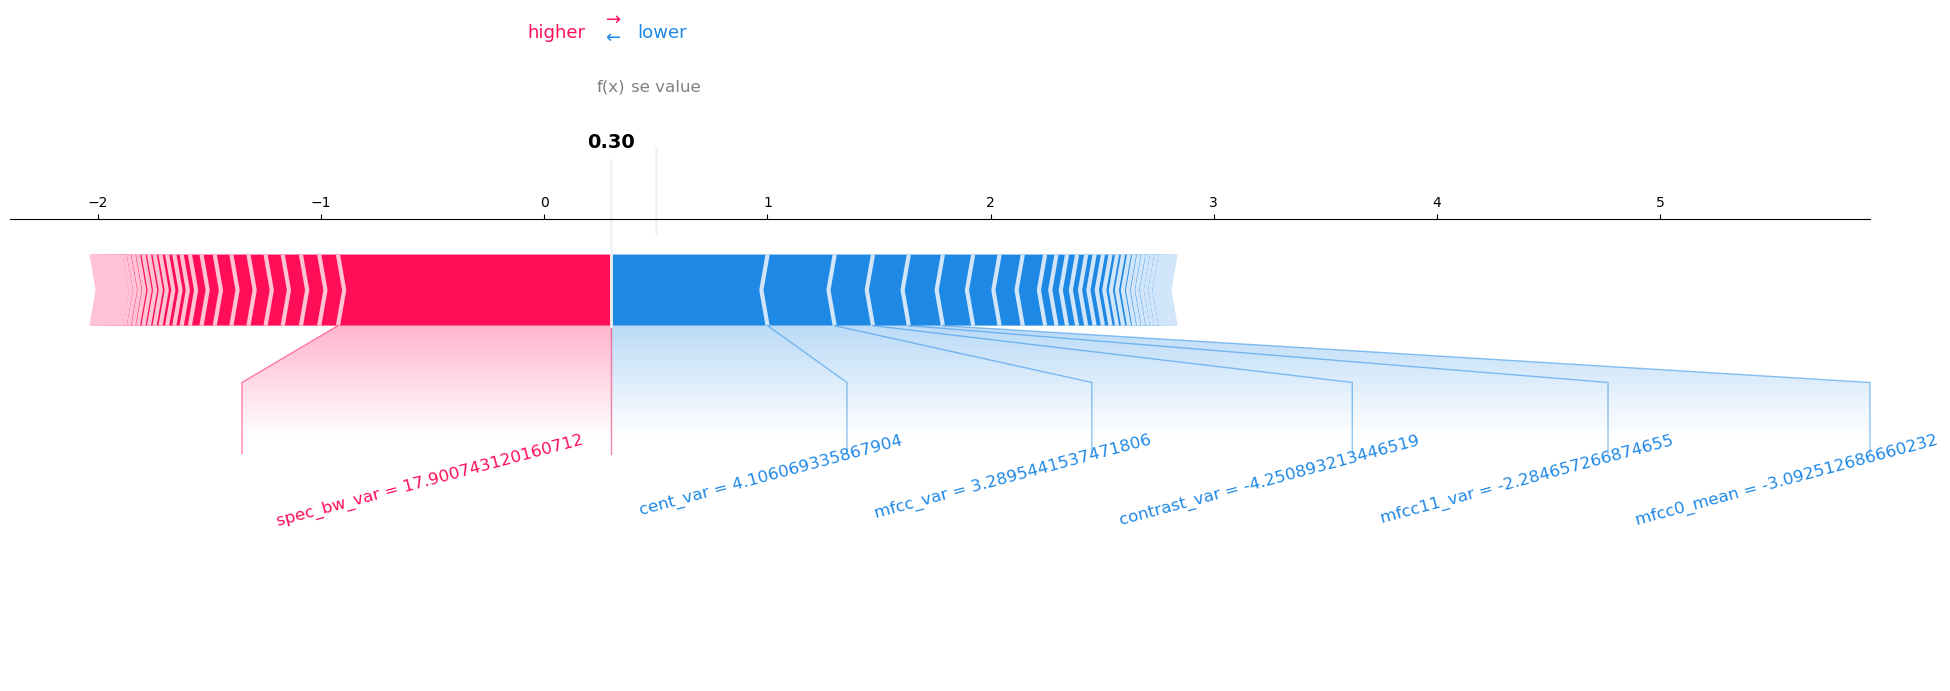

In [24]:
'''
Fit the explainer on a subset of the data (you can try all but then gets slower)
Return approximate SHAP values for the model applied to the data given by X.
Plot the local feature importance with a force plot and explain your observations.
'''
# YOUR CODE HERE

# Convert training data to tensor
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32).to(device)

# Create DeepExplainer using training dataset as background
explainer = shap.DeepExplainer(model, X_train_tensor)

# Compute SHAP values for the test sample
shap_values = explainer.shap_values(X_tensor)

# Force plot for local feature importance
shap.initjs()
feature_names = df.drop(columns=['filename']).columns.tolist()

shap.force_plot(
    explainer.expected_value[0],
    shap_values[0, :, 0],
    X_test_scaled_eg[0],
    feature_names = feature_names,
    matplotlib = True,
    figsize = (24, 6),
    text_rotation = 15,
    show = True
)

In [41]:
N = 10  # Top N important features
shap_vals_1d = shap_values[0, :, 0]

features_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP Value': shap_vals_1d,
    'Absolute SHAP': np.abs(shap_vals_1d)
}).sort_values('Absolute SHAP', ascending=False).head(N).reset_index(drop=True)

features_df['Colour']    = features_df['SHAP Value'].apply(lambda x: 'Red' if x > 0 else 'Blue')
features_df['Direction'] = features_df['SHAP Value'].apply(lambda x: 'Pushes towards class 1 (+)' if x > 0 else 'Pushes towards class 0 (-)')
features_df.index        = range(1, N + 1)
features_df.index.name   = 'Rank'

features_df = features_df.drop(columns=['Absolute SHAP'])

print(f"Top {N} Most Important Features:")
display(features_df)

Top 10 Most Important Features:


,Feature,SHAP Value,Colour,Direction
Rank,,,,
1,spec_bw_var,1.225194,Red,Pushes towards class 1 (+)
2,cent_var,-0.699732,Blue,Pushes towards class 0 (-)
3,mfcc_var,-0.300633,Blue,Pushes towards class 0 (-)
4,contrast_var,-0.171555,Blue,Pushes towards class 0 (-)
5,mfcc11_var,-0.160545,Blue,Pushes towards class 0 (-)
6,mfcc0_mean,-0.152628,Blue,Pushes towards class 0 (-)
7,mfcc14_mean,-0.135737,Blue,Pushes towards class 0 (-)
8,mfcc3_var,-0.118362,Blue,Pushes towards class 0 (-)
9,mfcc9_var,-0.103888,Blue,Pushes towards class 0 (-)


As we can see from the force plot above, spec_bw_var is the single most dominant feature with a SHAP value of +1.2252, acting as a red feature that pushes the prediction towards class 1. However, despite its strong individual influence, it is outvoted by the collective contribution of multiple blue features pushing towards class 0. 

The next two most important features, cent_var (SHAP = -0.6997) and mfcc_var (SHAP = -0.3006), both push towards class 0, and together with other smaller blue features such as mfcc0_mean and mfcc1_var, their cumulative negative contributions outweigh spec_bw_var's positive push. This shifts the 
final prediction from the base value of around 0.5 down to 0.30, which falls below the 0.5 classification threshold, resulting in a final predicted label of class 0. 

This demonstrates that the model's decision is not driven by a single feature, but rather the combined effect of multiple features, highlighting the importance of considering all feature contributions holistically rather than focusing solely on the most dominant one.